<a href="https://colab.research.google.com/github/IsaaHack/VC/blob/main/P2_Ej3_TEMPLATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visión por Computador - Práctica 2 - Deep Learning en Computer Vision

#### 12 puntos   |   Fecha de entrega: 15 de Diciembre, 23:59   |   Forma de entrega: a través de la tarea creada en https://pradogrado2425.ugr.es/

### Estudiante: <mark>ISAAC BRAO AISSAONI</mark>

# <font color='blue'>**Ejercicio  3: Transfer Learning y fine-tuning con ResNet50 en el SPR X-Ray Age Prediction Challenge (3.5 points)**
<font color='blue'>En este ejercicio trabajaremos con el _SPR X-Ray Age Prediction Challenge_ de Kaggle (https://www.kaggle.com/competitions/spr-x-ray-age/data). Este dataset consta de $10 702$ radiografías de tórax, y el objetivo es predecir la edad de la persona a partir de la imagen de la radiografía. En esta ocasión, se emplearán $6 702$ imágenes para entrenamiento y $4 000$ para test. Las edades oscilan entre los 18 y los 89 años. Para facilitar el trabajo al alumnado se proporciona una versión procesada de los datos (con resolución $224\times224$, en lugar de $1024\times1024$, y empleando solo ejemplos para los cuales se tiene salida deseada (dado que, al tratarse de una challenge de kaggle, el conjunto de test está disponible pero sin etiquetar)). Estos datos se pueden acceder desde: https://drive.google.com/drive/folders/1hCWfTLs1w0h5kObl6NEIhEtH5VDmmCnj?usp=sharing (se debe emplear una cuenta de la UGR para acceder a dicha URL, y la información allí contenida (directorio `spr-x-ray-age`) se debe incluir en la carpeta `Colab Notebooks`).

<font color='blue'>Se debe emplear un $20\%$ de los datos de entrenamiento para validación, y el rendimiento debe ser evaluado, como mínimo, por medio de $MSE$, $MAE$ y $R^2$ _(coefficient of determination) score_. Se deben justificar las decisiones tomadas, como la elección de la función de pérdida. Del mismo modo, es necesario hacer un `summary()` de las arquitecturas empleadas en cada apartado, indicando qué parámetros/capas/bloques son entrenables y cuáles no lo son (es decir, en cada apartado es imprescindible destacar claramente qué arquitectura exacta se está utilizando, así como qué pesos se están entrenando y cuáles se están congelando).

<font color='blue'>Usaremos un modelo ResNet50 pre-entrenado en ImageNet, y tendremos que realizar los siguientes experimentos en relación a la estrategia de entrenamiento:

<font color='blue'>1. Partimos de ResNet50, adaptamos la cabecera (sustituyendo la cabecera anterior por *una única fully-connected* con el número de neuronas de salida adecuado), y reentrenamos (_from scratch_) la red entera para este nuevo problema. Es decir, partimos de pesos aleatorios para resolver este problema de regresión.

<font color='blue'>2. Partimos de ResNet50, adaptamos la cabecera (empleando la misma del apartado anterior), y entrenamos solo la cabecera incorporada. Es decir, ResNet50 se usa como un mero extractor de características, y los pesos que se entrenan son los de la nueva capa incorporada (manteniendo fijos/congelados todos los demás).  

<font color='blue'>3. Partimos de ResNet50, dejamos que fastai incorpore su cabecera por defecto (véase https://wandb.ai/capecape/imagenette_timm/reports/Checking-Out-the-New-fastai-timm-Integration--VmlldzoxOTMzNzMw o https://docs.fast.ai/vision.learner.html#head-and-model), y entrenamos solo la cabecera incorporada. Es decir, de nuevo, ResNet50 se usa como extractor de características, y los pesos que se entrenan son los de las nuevas capas incorporadas

<font color='blue'>4. Partimos de ResNet50, adaptamos la cabecera (puede ser la del apartado 3.2 o la del 3.3), y hacemos un ajuste fino de toda la red partiendo de los pesos de ResNet50 (preentrenada en ImageNet).



<font color='blue'>Es importante remarcar que estamos intentando resolver un problema de regresión por medio de la reutilización de un modelo pre-entrenado en un problema de clasificación (ImageNet). ¿Tiene sentido hacerlo? ¿Por qué nos sirven pesos entrenados en clasificación para un problema de regresión? ¿No son, acaso, problemáticas muy diferentes?

Lo importante es que la red haya aprendido características útiles para la tarea de clasificación en ImageNet, y que estas características sean útiles para la tarea de regresión en el dataset de radiografías de tórax. Por ejemplo, es posible que la red haya aprendido a detectar bordes, formas, texturas, etc., que sean útiles para la tarea de regresión. Es algo que se hace habitualmente en Deep Learning, y que se conoce como _transfer learning_.

In [ ]:
# The first thing we should do is to apply hardware acceleration via GPU. So, we have to go to Editar - Configuracion del Cuaderno - Acelerador por Hardware GPU

# Now we SET UP Fastai
!pip install -Uqq fastbook
!pip install nbdev
import fastbook
fastbook.setup_book()
import fastai
import fastcore
print(f'fastcore version {fastcore.__version__} installed')
print(f'fastai version {fastai.__version__} installed')
from nbdev.showdoc import *
from fastai.vision.all import *

fastcore version 1.7.19 installed
fastai version 2.7.18 installed


In [ ]:
# Function to display evaluation metrics
# Developed by Ignacio Oguiza: https://forums.fast.ai/t/plotting-metrics-after-learning/69937

@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()

In [ ]:
# defining the paths to images and labels
train_folder = 'gdrive/MyDrive/Colab Notebooks/spr-x-ray-age/train'
test_folder = 'gdrive/MyDrive/Colab Notebooks/spr-x-ray-age/test'
csv_path = 'gdrive/MyDrive/Colab Notebooks/spr-x-ray-age/All_labels.csv'
#train_folder = 'spr-x-ray-age/train'
#test_folder = 'spr-x-ray-age/test'
#csv_path = 'spr-x-ray-age/All_labels.csv'

In [ ]:
if os.path.exists(csv_path):
    print("CSV File exists!")
    # reading the labels dataframe
    df = pd.read_csv(csv_path, dtype=float, index_col=0)
    print(f'Dataframe shape: {df.shape}')
else:
    print("File does not exist.")

CSV File exists!
Dataframe shape: (10702, 1)


In [ ]:
# defining the dataset paths
train_path = Path(train_folder)
test_path = Path(test_folder)

# reading the folders looking for images
train_files = get_image_files(train_path)
test_files = sorted(get_image_files(test_path))

print(f'{len(train_files)} files were found for training and {len(test_files)} files were found for test')

6702 files were found for training and 4000 files were found for test


Age varies from 18.0 to 89.0



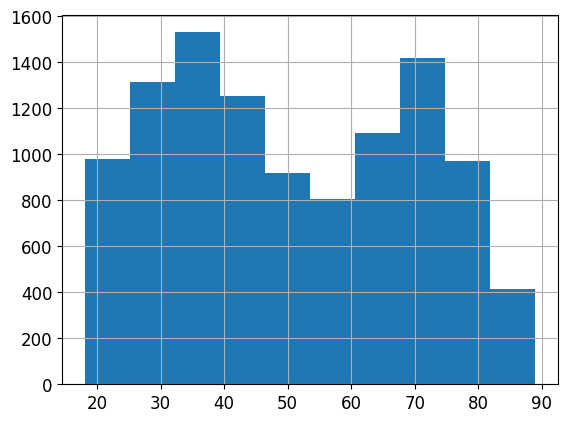

In [ ]:
print(f'Age varies from {df.age.min()} to {df.age.max()}\n')
_=df.age.hist()

In [ ]:
# function used to retun the label from an image
def label_func(file):
    # takes the file's base name w/o the extension
    basename = int(os.path.basename(str(file)).split('.')[0])

    # searches for the label
    label = int(df.age[basename])

    return label

En el DataBlock, vamos a usar el bloque de regresión de fastai, que es `RegressionBlock()`, que añade la función de activalión que se usa en regresión, que es la función de activación identidad.

Vamos a usar un batch size de 64, un tamaño de imagen de 224x224, y un tamaño de validación del 20%.

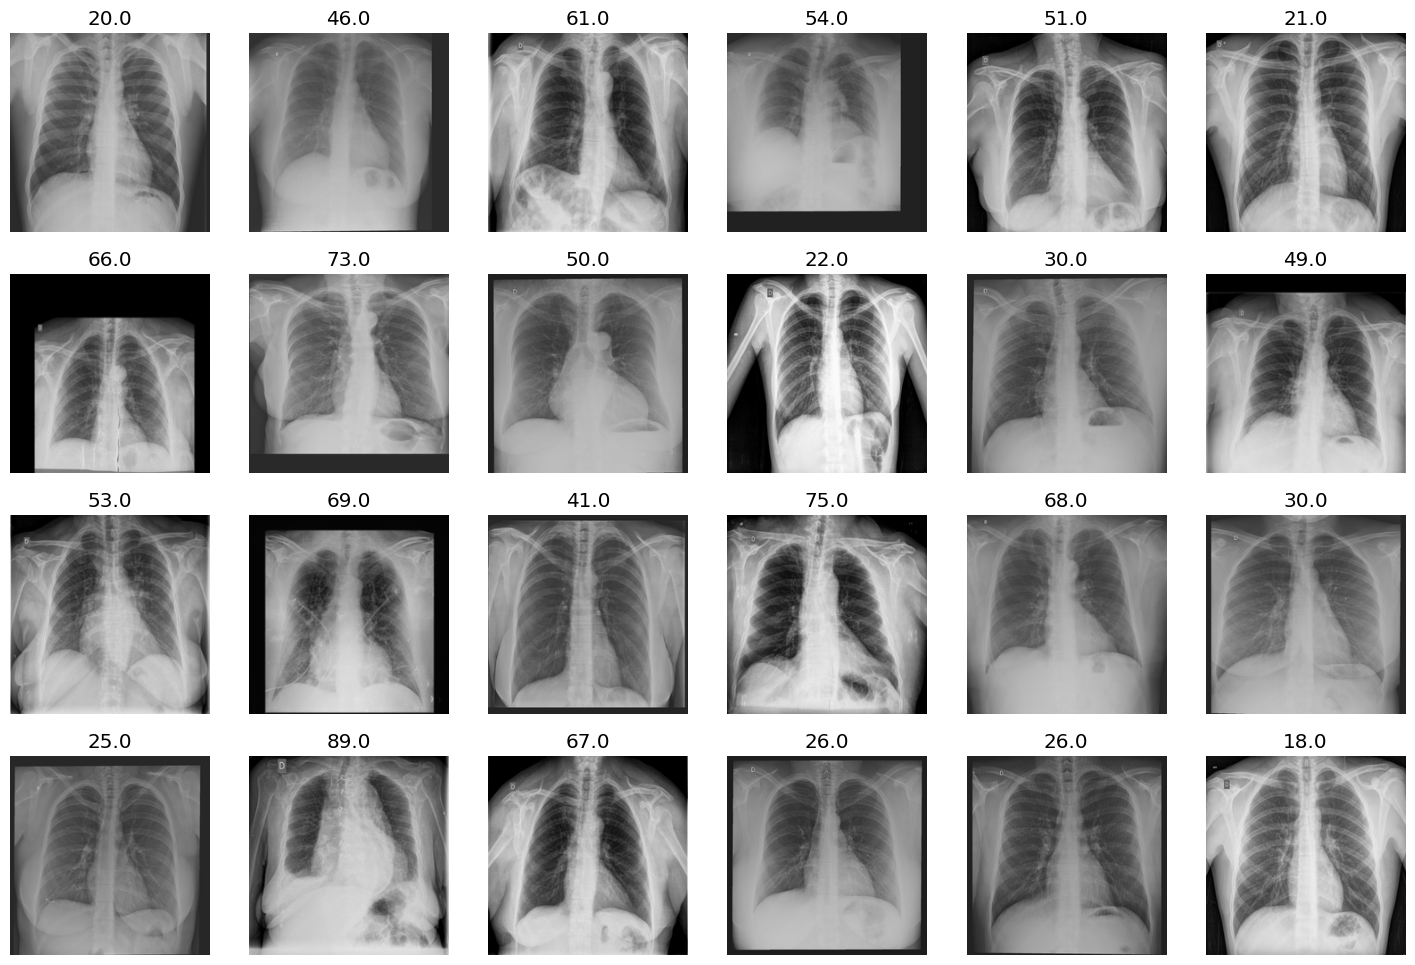

In [ ]:
# defines the image dataloader
dtblk = DataBlock(
    blocks=(ImageBlock, RegressionBlock),
    get_y=label_func,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    batch_tfms=Normalize()
)
dls = dtblk.dataloaders(train_files, bs=64)

# shows some samples
dls.show_batch(max_n=24)

## <font color='blue'>3.1 Entrenamos todo ResNet50 _from scratch_, ajustando la cabecera para este problema.

Vamos a usar una cabecera con una capa lineal con 1 salida, que es la edad de la persona. Vamos a usar el optimizador Adam, y vamos a entrenar durante 10 épocas.

Vamos a usar el MSE como función de pérdida, porque es una función de pérdida adecuada para problemas de regresión y penaliza más los errores grandes que los pequeños.

Para custumizar la cabecera, vamos a usar un bloque secuencial de fastai, que es `nn.Sequential()`, con un AdaptiveAVGPool2d, un Flatten y un Linear. El AdaptiveAVGPool2d es una capa que hace un promedio de los valores de las características de la última capa convolucional, y permite que la entrada para las capas densas sea siempre la misma y solo dependa del número de filtros, en este caso 2048.

Usamos pre-trained=False para que no se carguen los pesos pre-entrenados que hay en la red ResNet50.

También vamos a reducir la precisión del cálculo de los gradientes a 16 bits, para acelerar el entrenamiento. Para ello, vamos a usar el callback `MixedPrecision()` de fastai. En concreto vamos a utilizar `to_bf16()` que es una forma especial de reducir la precisión de los cálculos a 16 bits. No reduce el rango de los valores, pero sí la distancia entre ellos. Una ventaja de usar este método es que el entrenamiento es más estable que si usasemos `to_fp16()`, que reduce el rango de los valores y produce truncamiento a 0, lo que puede provocar divisiones por 0.

`MixedPrecision()` es un callback que se encarga de cambiar la precisión de los cálculos de los gradientes a 16 bits, y de cambiar la precisión de los cálculos de los pesos a 32 bits. En layers como batchnorm, que no se ven afectadas por la reducción de la precisión, se mantienen los cálculos a 32 bits, porque son más susceptibles a errores de precisión.

**MIRAR** **->** https://docs.fast.ai/callback.fp16.html

Uso las métricas MSE, MAE y R2 para evaluar el rendimiento del modelo, como se pide en el enunciado.

- MSE: Mean Squared Error, que es la media de los errores al cuadrado. Es una métrica que penaliza más los errores grandes que los pequeños.
- MAE: Mean Absolute Error, que es la media de los valores absolutos de los errores. Es una métrica que no penaliza tanto los errores grandes como el MSE, pero está en las mismas unidades que la variable que estamos prediciendo, por lo que es más fácil de interpretar.
- R2: Coeficiente de determinación, que es una métrica que mide la proporción de la varianza en la variable dependiente que es predecible a partir de la variable independiente. Puede tomar valores entre 0 y 1, y cuanto más cerca de 1, mejor es el modelo. Si es 0, el modelo no es mejor que predecir la media de la variable dependiente. Si es negativo, el modelo es peor que predecir la media de la variable dependiente.

Creo que la R2 es la más fácil de interpretar, porque se parece más a un porcentaje, y cuanto más cerca de 1, mejor es el modelo. Por lo que es la que analizaré más detenidamente.

In [ ]:
#Libera la memoria de la GPU
torch.cuda.empty_cache()

# Obtener el modelo ResNet50 para entrenarlo from scratch y ajustar la cabecera para que se ajuste a la regresión

custom_head = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),

    nn.Flatten(),

    nn.Linear(in_features=2048, out_features=1)
)

#Reduzco la precisión a 16 bits para acelerar el entrenamiento

resnet50_scratch = vision_learner(dls, resnet50, loss_func=MSELossFlat(), metrics=[mse, mae, R2Score()], pretrained=False, custom_head=custom_head).to_bf16()

In [ ]:
resnet50_scratch.summary()

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    4096       True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
____________________________________________________________________________
                     64 x 256 x 56 x 56  
Conv2d                                    16384      True      
BatchNorm2d                        

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

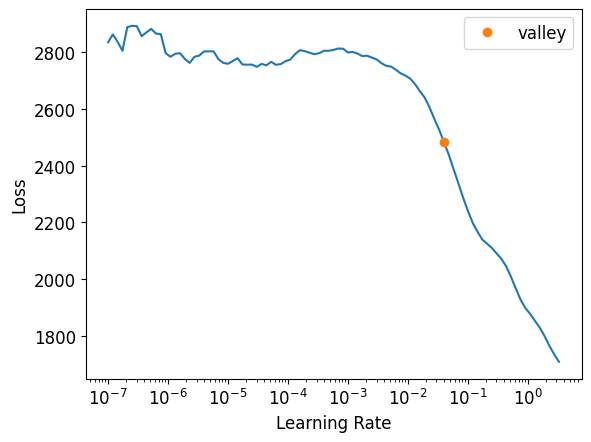

In [ ]:
lr = resnet50_scratch.lr_find()

In [ ]:
resnet50_scratch.fit_one_cycle(10, lr, cbs=EarlyStoppingCallback(patience=3))

epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,1091.751099,346.422424,346.422424,16.120708,0.004983,00:21
1,451.331116,389.787262,389.787262,16.352798,-0.119572,00:20
2,269.372345,272.316467,272.316467,13.499440,0.217835,00:20
3,177.473022,148.373703,148.373703,9.732742,0.573831,00:21
4,139.264252,211.997391,211.997391,11.673041,0.391087,00:22
5,118.147781,120.172760,120.172760,8.689925,0.654832,00:23
6,99.907585,124.161011,124.161011,8.701492,0.643377,00:24
7,79.848709,113.322350,113.322350,8.312779,0.674508,00:25
8,59.274063,106.285515,106.285515,8.105411,0.694720,00:25
9,45.893425,107.083710,107.083710,8.165205,0.692427,00:26


El modelo consigue un R2 de 0.69, lo que significa que el 69% de la varianza de la variable dependiente es predecible a partir de la variable independiente. Es un valor bastante bueno, pero se podría mejorar.

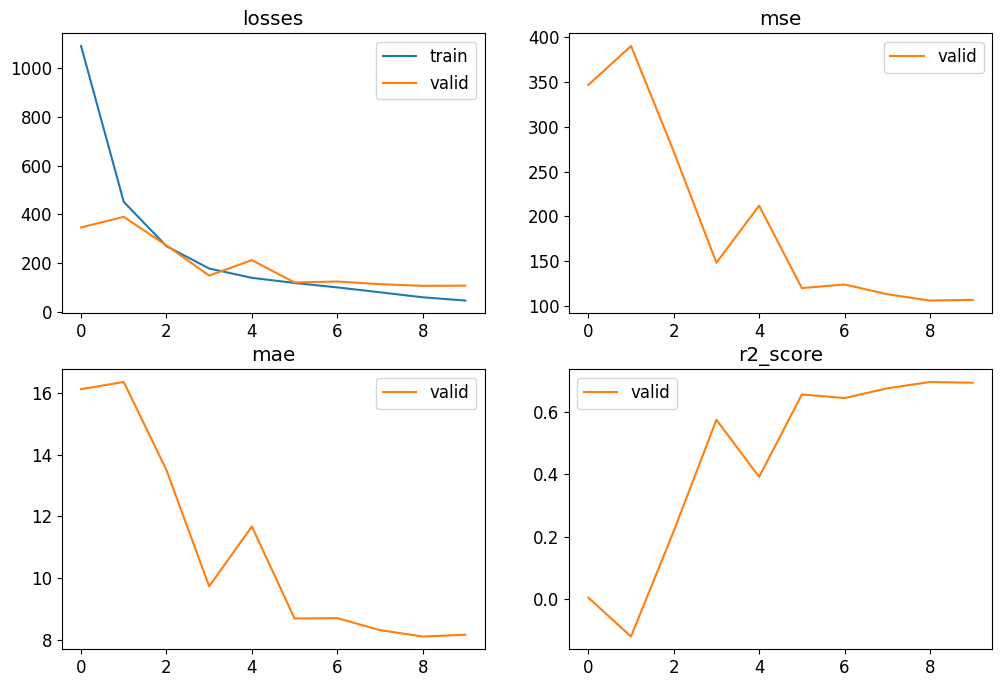

In [ ]:
resnet50_scratch.recorder.plot_metrics()

Aunque no se observa en la gráfica, el modelo sobreajusta bastante.

In [ ]:
# Accuracy en training y validación
preds, targs = resnet50_scratch.get_preds(dl=dls.train)
mse_train = fastai.metrics.mse(preds, targs)
mae_train = fastai.metrics.mae(preds, targs)
r2_train = fastai.metrics.R2Score()(preds, targs)

preds, targs = resnet50_scratch.get_preds(dl=dls.valid)
mse_valid = fastai.metrics.mse(preds, targs)
mae_valid = fastai.metrics.mae(preds, targs)
r2_valid = fastai.metrics.R2Score()(preds, targs)

print('MSE en training:', float(mse_train))
print('MAE en training:', float(mae_train))
print('R2 en training:', float(r2_train), '\n')

print('MSE en validación:', float(mse_valid))
print('MAE en validación:', float(mae_valid))
print('R2 en validación:', float(r2_valid))

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


MSE en training: 33.2183952331543
MAE en training: 4.606956481933594
R2 en training: 0.9032447338104248 

MSE en validación: 107.08370971679688
MAE en validación: 8.165205001831055
R2 en validación: 0.6924271583557129


In [ ]:
test_dl = resnet50_scratch.dls.test_dl(test_files, with_labels=True)
preds, targs = resnet50_scratch.get_preds(dl=test_dl)
mse_ = fastai.metrics.rmse(preds, targs)
mae_ = fastai.metrics.mae(preds, targs)
r2_ = fastai.metrics.R2Score()(preds, targs)

print('MSE en test: ', float(mse_))
print('MAE en test: ', float(mae_))
print('R2 en test: ', float(r2_))

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


MSE en test:  10.354218482971191
MAE en test:  8.090906143188477
R2 en test:  0.7219316363334656


Se ve que el R2 de validación y entrenamiento son muy parecidos, lo que indica que el modelo generaliza bien, pero no es tan parecido a entrenamiento porque el modelo sobreajusta.

## <font color='blue'>3.2. ResNet50 se usa como extractor de características: Entrenamos solo la cabecera incorporada.



Esta vez ponemos pre-trained=True para que se carguen los pesos pre-entrenados de la red ResNet50.

Con esto se congela la red ResNet50, y solo se entrenan los pesos de la cabecera que hemos añadido y los pesos de batchnorm.

Los pesos de batchnorm se entrenan porque son necesarios para que la red aprenda a normalizar los datos de entrada, si no se hace la red tendrá peor rendimiento. Es lo que se suele hacer en transfer learning, congelar la red y entrenar solo los pesos de la cabecera y de batchnorm.

In [ ]:
#Libera la memoria de la GPU
torch.cuda.empty_cache()

custom_head = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),

    nn.Flatten(),

    nn.Linear(in_features=2048, out_features=1)
)

# Obtener el modelo ResNet50 pre-entrenado y ajustar la cabecera para que se ajuste a la regresión

resnet50_pretrained = vision_learner(dls, resnet50, loss_func=MSELossFlat(), metrics=[mse, mae, R2Score()], pretrained=True, custom_head=custom_head).to_bf16()

In [ ]:
resnet50_pretrained.summary()

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    4096       False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
____________________________________________________________________________
                     64 x 256 x 56 x 56  
Conv2d                                    16384      False     
BatchNorm2d                        

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

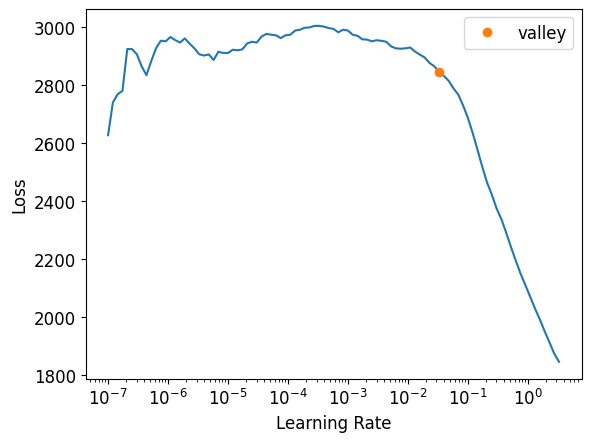

In [ ]:
lr = resnet50_pretrained.lr_find()

In [ ]:
resnet50_pretrained.fit_one_cycle(10, lr, cbs=EarlyStoppingCallback(patience=3))

epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,2266.994873,1530.000366,1530.000366,34.919006,-3.394567,00:20
1,490.197296,84.354454,84.354454,7.021082,0.757712,00:20
2,138.250610,63.615940,63.615940,6.217257,0.817278,00:21
3,64.578590,81.299782,81.299782,7.101912,0.766485,00:23
4,48.404247,57.268284,57.268284,5.911194,0.835510,00:23
5,36.200356,60.878254,60.878254,6.086707,0.825141,00:24
6,26.549601,76.584373,76.584373,6.988993,0.780029,00:25
7,20.909412,53.785694,53.785694,5.763340,0.845513,00:25
8,14.570194,52.371593,52.371593,5.625933,0.849575,00:26
9,12.932605,53.181519,53.181519,5.708302,0.847249,00:26


Obtenemos significativamente mejores resultados que en el apartado anterior, con un R2 de 0.85.. Es un valor bastante bueno, lo que significa que el conoimiento que ha adquirido la red en ImageNet es muy útil para la tarea de regresión en el dataset de radiografías de tórax.

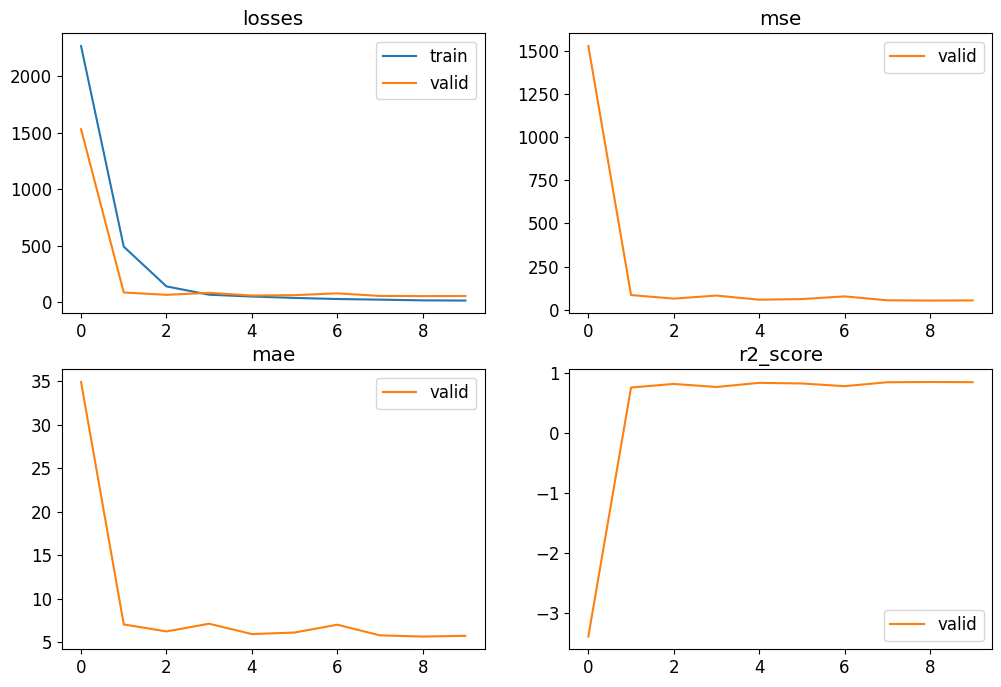

In [ ]:
resnet50_pretrained.recorder.plot_metrics()

La red sigue sobreajustando.

In [ ]:
# Accuracy en training y validación
preds, targs = resnet50_pretrained.get_preds(dl=dls.train)
mse_train = fastai.metrics.mse(preds, targs)
mae_train = fastai.metrics.mae(preds, targs)
r2_train = fastai.metrics.R2Score()(preds, targs)

preds, targs = resnet50_pretrained.get_preds(dl=dls.valid)
mse_valid = fastai.metrics.mse(preds, targs)
mae_valid = fastai.metrics.mae(preds, targs)
r2_valid = fastai.metrics.R2Score()(preds, targs)

print('MSE en training:', float(mse_train))
print('MAE en training:', float(mae_train))
print('R2 en training:', float(r2_train), '\n')

print('MSE en validación:', float(mse_valid))
print('MAE en validación:', float(mae_valid))
print('R2 en validación:', float(r2_valid))

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


MSE en training: 5.893183708190918
MAE en training: 1.9338866472244263
R2 en training: 0.9828349351882935 

MSE en validación: 53.1815185546875
MAE en validación: 5.708302021026611
R2 en validación: 0.8472485542297363


In [ ]:
test_dl = resnet50_pretrained.dls.test_dl(test_files, with_labels=True)
preds, targs = resnet50_pretrained.get_preds(dl=test_dl)
mse_ = fastai.metrics.mse(preds, targs)
mae_ = fastai.metrics.mae(preds, targs)
r2_ = fastai.metrics.R2Score()(preds, targs)

print('MSE en test: ', float(mse_))
print('MAE en test: ', float(mae_))
print('R2 en test: ', float(r2_))

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


MSE en test:  45.452606201171875
MAE en test:  5.231281280517578
R2 en test:  0.8821103572845459


Vemos mucho mejores resultados. Se generaliza mejor y sobreajusta un poco menos.

## <font color='blue'>3.3. ResNet50 se usa como extractor de características: Entrenamos solo la cabecera incorporada por defecto por fastai.



Ahora vamos a dejar que fastai incorpore su cabecera por defecto.

In [ ]:
#Libera la memoria de la GPU
torch.cuda.empty_cache()

# Obtener el modelo ResNet50 pre-entrenado y con la cabeza por defecto de fastai

resnet50_pretrained_default_head = vision_learner(dls, resnet50, loss_func=MSELossFlat(), metrics=[mse, mae, R2Score()], pretrained=True).to_bf16()

In [ ]:
resnet50_pretrained_default_head.summary()

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    4096       False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
____________________________________________________________________________
                     64 x 256 x 56 x 56  
Conv2d                                    16384      False     
BatchNorm2d                        

Vemos que aplica AdaptiveAvgPool2d, AdaptiveMaxPool2d, Flatten y Linear. Es muy parecido a lo que hemos hecho en el apartado anterior. Solamente ha añadido más capas densas, AdaptiveMaxPool2d y aumentado los canales que van al flatten.

La cabecera por defecto de fastai es mejor que la que hemos hecho nosotros, porque ha añadido más capas densas, lo que le permite aprender más características de los datos.

/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

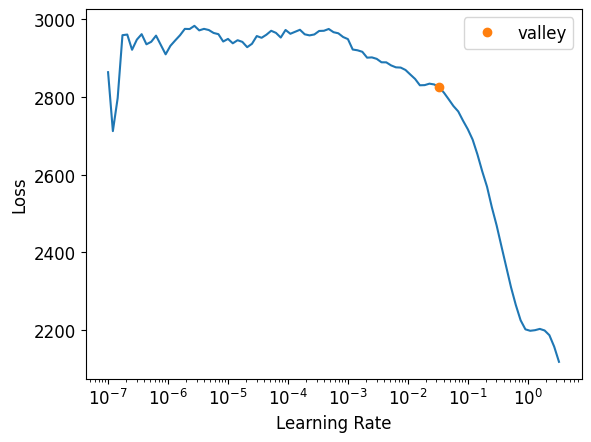

In [ ]:
lr = resnet50_pretrained_default_head.lr_find()

In [ ]:
resnet50_pretrained_default_head.fit_one_cycle(10, lr, cbs=EarlyStoppingCallback(patience=3))

epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,2419.895264,1909.074951,1909.074951,39.879688,-4.483369,00:22
1,954.272888,249.236328,249.236328,13.307696,0.284127,00:24
2,258.426575,85.991684,85.991684,7.184235,0.753009,00:27
3,109.419601,77.194962,77.194962,6.792911,0.778276,00:27
4,73.773003,83.249474,83.249474,7.143750,0.760885,00:28
5,60.514614,64.422455,64.422455,6.246269,0.814962,00:28
6,51.234570,58.316406,58.316406,5.905130,0.832500,00:30
7,42.099361,55.538036,55.538036,5.776865,0.840480,00:31
8,36.712181,55.465801,55.465801,5.807743,0.840688,00:29
9,31.834911,55.571316,55.571316,5.791791,0.840384,00:28


Vemos que no ha mejorado los resultados, pero ha disminuido el sobreajuste. Esto no me lo esperaba, porque la cabecera por defecto de fastai es mejor que la que hemos hecho nosotros, pero los resultados son peores. Esto puede ser porque la cabecera por defecto de fastai es más compleja, y necesita más épocas para aprender los pesos adecuados.

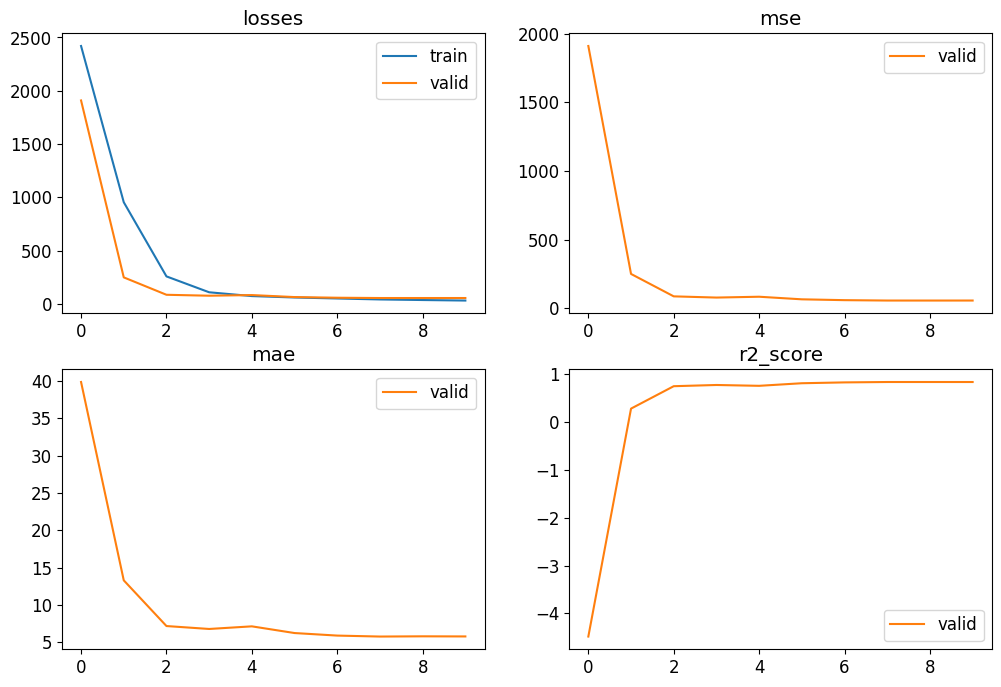

In [ ]:
resnet50_pretrained_default_head.recorder.plot_metrics()

El sobreajuste es muy bajo.

In [ ]:
# Accuracy en training y validación
preds, targs = resnet50_pretrained_default_head.get_preds(dl=dls.train)
mse_train = fastai.metrics.mse(preds, targs)
mae_train = fastai.metrics.mae(preds, targs)
r2_train = fastai.metrics.R2Score()(preds, targs)

preds, targs = resnet50_pretrained_default_head.get_preds(dl=dls.valid)
mse_valid = fastai.metrics.mse(preds, targs)
mae_valid = fastai.metrics.mae(preds, targs)
r2_valid = fastai.metrics.R2Score()(preds, targs)

print('MSE en training:', float(mse_train))
print('MAE en training:', float(mae_train))
print('R2 en training:', float(r2_train), '\n')

print('MSE en validación:', float(mse_valid))
print('MAE en validación:', float(mae_valid))
print('R2 en validación:', float(r2_valid))

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


MSE en training: 13.262334823608398
MAE en training: 2.8891971111297607
R2 en training: 0.9613707661628723 

MSE en validación: 55.57131576538086
MAE en validación: 5.791790962219238
R2 en validación: 0.8403844237327576


In [ ]:
test_dl = resnet50_pretrained_default_head.dls.test_dl(test_files, with_labels=True)
preds, targs = resnet50_pretrained_default_head.get_preds(dl=test_dl)
mse_ = fastai.metrics.mse(preds, targs)
mae_ = fastai.metrics.mae(preds, targs)
r2_ = fastai.metrics.R2Score()(preds, targs)

print('MSE en test: ', float(mse_))
print('MAE en test: ', float(mae_))
print('R2 en test: ', float(r2_))

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


MSE en test:  48.621482849121094
MAE en test:  5.4085001945495605
R2 en test:  0.8738912343978882


Los resultados son un poco peores que en el apartado anterior, pero el sobreajuste es mucho menor.

## <font color='blue'>3.4. Hacemos un ajuste fino (fine-tuning) de toda la red partiendo de los pesos de ImageNet.

Finalmente vamos a hacer un ajuste fino de toda la red, partiendo de los pesos de ImageNet, del apartado 3.3.

In [ ]:
#Libera la memoria de la GPU
torch.cuda.empty_cache()

resnet50_pretrained_default_head = vision_learner(dls, resnet50, loss_func=MSELossFlat(), metrics=[mse, mae, R2Score()], pretrained=True).to_bf16()

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


/opt/conda/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

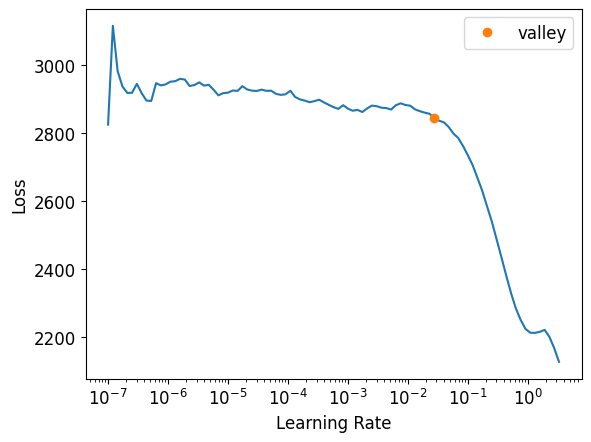

In [ ]:
lr = resnet50_pretrained_default_head.lr_find()

In [ ]:
#Ajuste fino con el modelo de ResNet50 pre-entrenado con la cabeza por defecto de fastai

resnet50_pretrained_default_head.fine_tune(10, cbs=EarlyStoppingCallback(patience=3), base_lr=lr[0])

epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,1833.541626,862.409790,862.409790,24.247948,-1.477069,00:23


/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,672.609314,545.794128,545.794128,18.736753,-0.567666,00:34
1,400.024719,255.878876,255.878876,13.275093,0.265048,00:35
2,236.997543,181.378906,181.378906,10.971175,0.479032,00:35
3,178.317322,157.622894,157.622894,10.065672,0.547265,00:35
4,148.390457,142.618607,142.618607,9.506717,0.590361,00:35
5,129.650604,132.613312,132.613312,9.132183,0.619099,00:35
6,120.786026,129.148773,129.148773,9.001352,0.629050,00:35
7,111.970581,126.772644,126.772644,8.920336,0.635875,00:36
8,107.962540,125.267189,125.267189,8.825373,0.640199,00:36
9,108.497681,124.839043,124.839043,8.837453,0.641429,00:37


Vemos que los resultados son peores que en el apartado 3.3, creo que es por el comportamiento de `fit_one_cycle`, que entrena mucho más rápido el modelo. Con fine-tuning, el modelo se entrena más lento, y no le da tiempo a aprender los pesos adecuados.

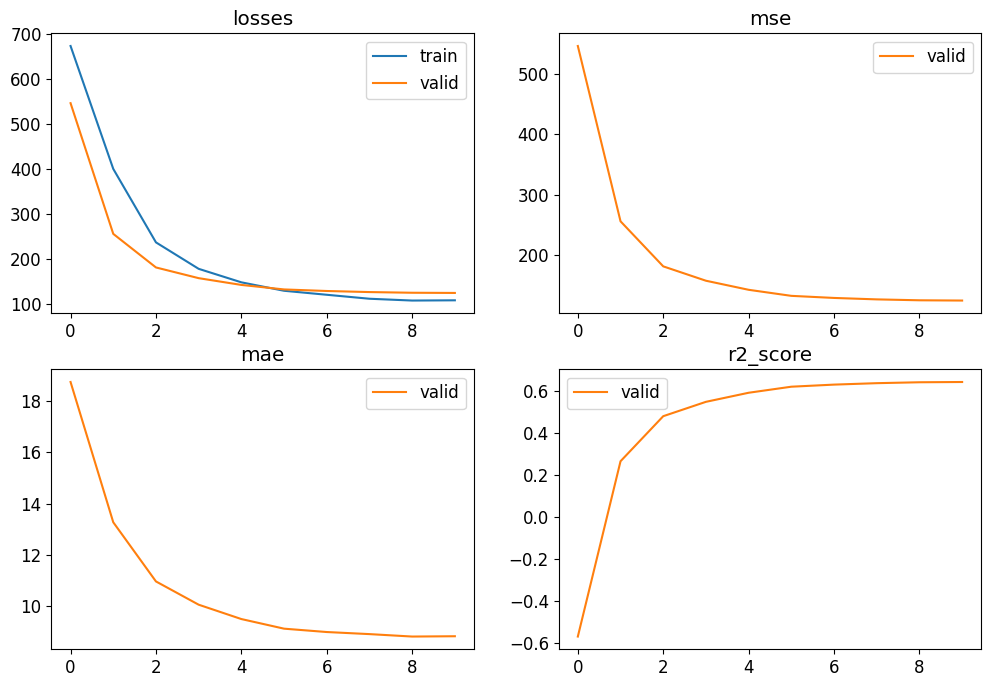

In [ ]:
resnet50_pretrained_default_head.recorder.plot_metrics()

In [ ]:
# Accuracy en training y validación
preds, targs = resnet50_pretrained_default_head.get_preds(dl=dls.train)
mse_train = fastai.metrics.mse(preds, targs)
mae_train = fastai.metrics.mae(preds, targs)
r2_train = fastai.metrics.R2Score()(preds, targs)

preds, targs = resnet50_pretrained_default_head.get_preds(dl=dls.valid)
mse_valid = fastai.metrics.mse(preds, targs)
mae_valid = fastai.metrics.mae(preds, targs)
r2_valid = fastai.metrics.R2Score()(preds, targs)

print('MSE en training:', float(mse_train))
print('MAE en training:', float(mae_train))
print('R2 en training:', float(r2_train), '\n')

print('MSE en validación:', float(mse_valid))
print('MAE en validación:', float(mae_valid))
print('R2 en validación:', float(r2_valid))

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


MSE en training: 83.37505340576172
MAE en training: 7.224205017089844
R2 en training: 0.7571534514427185 

MSE en validación: 124.83904266357422
MAE en validación: 8.83745288848877
R2 en validación: 0.6414291858673096


In [ ]:
test_dl = resnet50_pretrained_default_head.dls.test_dl(test_files, with_labels=True)
preds, targs = resnet50_pretrained_default_head.get_preds(dl=test_dl)
mse_ = fastai.metrics.mse(preds, targs)
mae_ = fastai.metrics.mae(preds, targs)
r2_ = fastai.metrics.R2Score()(preds, targs)

print('MSE en test: ', float(mse_))
print('MAE en test: ', float(mae_))
print('R2 en test: ', float(r2_))

/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/opt/conda/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


MSE en test:  123.00860595703125
MAE en test:  8.880156517028809
R2 en test:  0.68095463514328


Resultados mucho peores que en el apartado 3.3, y parecidos a los del apartado 3.1.

## <font color='blue'>Conclusiones. ¿Qué conclusiones se pueden extraer en base a toda la experimentación anterior? En caso de que nos enfrentemos a un nuevo problema, ¿qué opción, u opciones, de entre las anteriores, parece a priori la más razonable? ¿Por qué?

Las conclusiones que tengo es que lo mejor puede ser usar siempre lo aprendido en ImageNet, porque los resultados son mucho mejores que si entrenamos la red desde cero. También es mejor usar la cabecera por defecto de fastai, porque aunque los resultados son algo peores, el sobreajuste es mucho menor.

Después es mejor usar fit_one_cycle que fine-tuning, porque el modelo se entrena más rápido y los resultados son mejores. Creo que lo mejor sería usar fit_one_cycle durante unas pocas epocas, y después fine-tuning para mejorar los resultados a un ritmo más lento y seguro.